In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn tensorflow

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("stock_data (1).csv")

df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


In [10]:
df.columns

Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')

In [11]:
print(df.columns.tolist())

['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']


In [14]:
df.columns = df.columns.str.strip()

In [16]:
df.rename(columns={"Timestamp": "Date"}, inplace=True)

In [19]:
print(df.columns.tolist())

['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']


In [20]:
# Clean column names (remove spaces + lowercase)
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['unnamed: 0', 'stock_1', 'stock_2', 'stock_3', 'stock_4', 'stock_5'], dtype='object')


In [21]:
data = df[['stock_1']]
dataset = data.values

In [22]:
import pandas as pd

# Load data
df = pd.read_csv("stock_data (1).csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Print columns to confirm
print("Columns:", df.columns.tolist())

# Select one stock
data = df[['stock_1']]

# Convert to numpy
dataset = data.values

print("Data loaded successfully!")

Columns: ['unnamed: 0', 'stock_1', 'stock_2', 'stock_3', 'stock_4', 'stock_5']
Data loaded successfully!


In [23]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

In [24]:
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [25]:
def create_dataset(data, time_step=60):
    X, y = [], []
    
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

In [26]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [27]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

In [28]:
history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(X_test, y_test))

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 132ms/step - loss: 0.2609 - val_loss: 0.0292
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0387 - val_loss: 0.0321
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0204 - val_loss: 0.0217
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0145 - val_loss: 0.0397
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0130 - val_loss: 0.0285
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0106 - val_loss: 0.0241
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0098 - val_loss: 0.0242
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0092 - val_loss: 0.0201
Epoch 9/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0083 - val_loss: 0.0181
Epoch 10/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0077 - val_loss: 0.0157


In [29]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Inverse transform
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


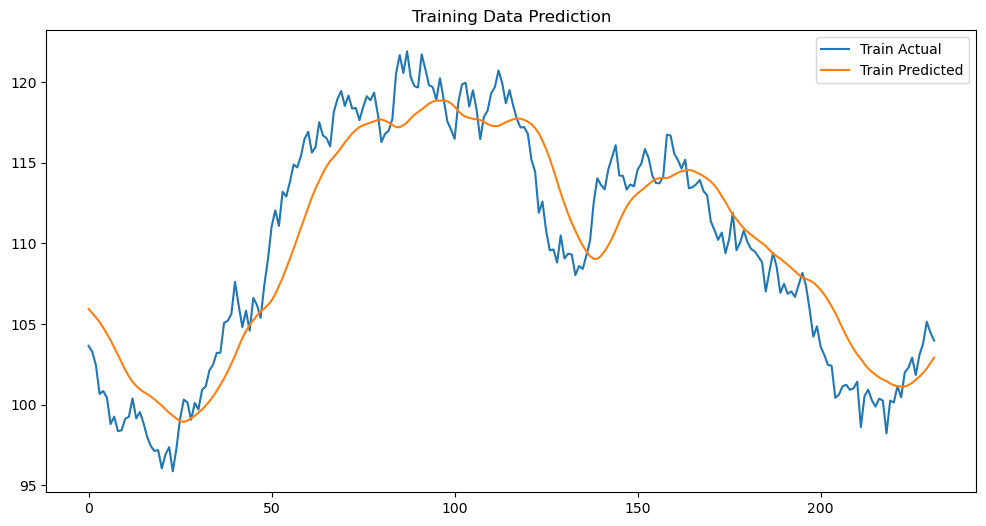

In [30]:
plt.figure(figsize=(12,6))

# Train
plt.plot(y_train_actual, label="Train Actual")
plt.plot(train_pred, label="Train Predicted")

plt.legend()
plt.title("Training Data Prediction")
plt.show()

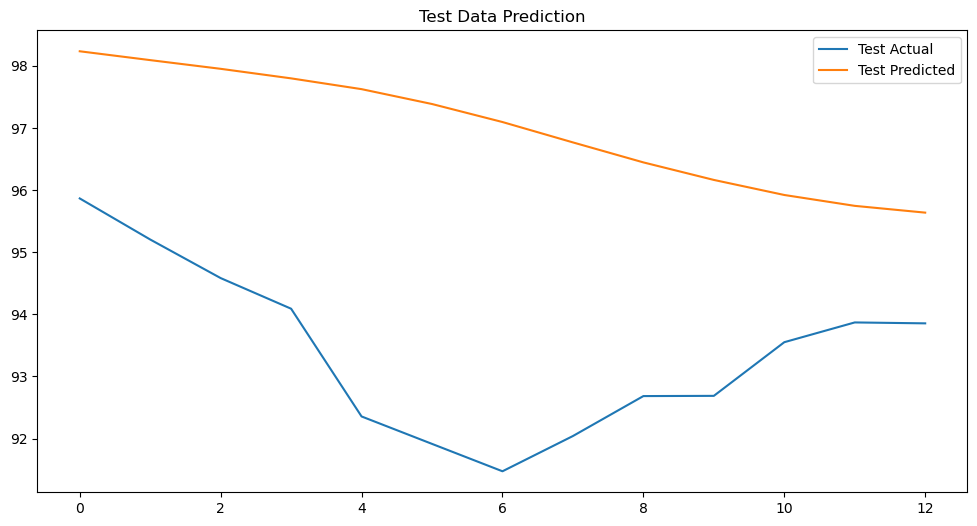

In [31]:
plt.figure(figsize=(12,6))

# Test
plt.plot(y_test_actual, label="Test Actual")
plt.plot(test_pred, label="Test Predicted")

plt.legend()
plt.title("Test Data Prediction")
plt.show()

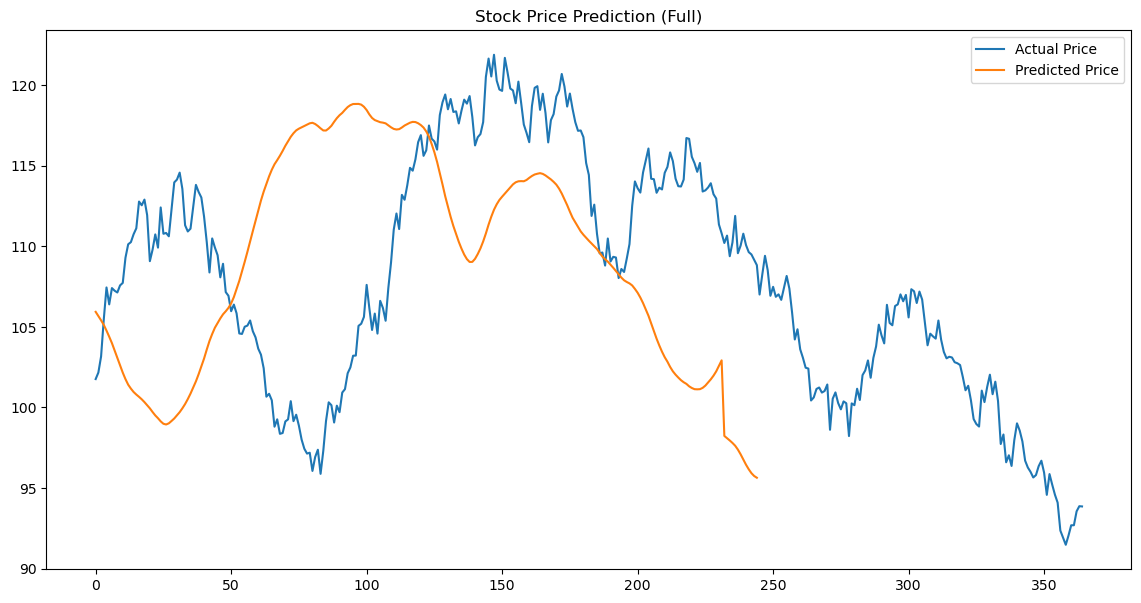

In [32]:
full_pred = np.concatenate((train_pred, test_pred))

plt.figure(figsize=(14,7))
plt.plot(dataset, label="Actual Price")
plt.plot(range(len(full_pred)), full_pred, label="Predicted Price")

plt.legend()
plt.title("Stock Price Prediction (Full)")
plt.show()

In [34]:
# Take last 60 values
last_60_days = scaled_data[-60:]

# Reshape to 3D
future_input = last_60_days.reshape(1, 60, 1)

future_predictions = []

for i in range(30):
    pred = model.predict(future_input, verbose=0)
    
    # Store prediction
    future_predictions.append(pred[0][0])
    
    # Reshape prediction to 3D (IMPORTANT FIX)
    pred_reshaped = pred.reshape(1,1,1)
    
    # Append correctly
    future_input = np.concatenate((future_input[:,1:,:], pred_reshaped), axis=1)

# Convert back to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

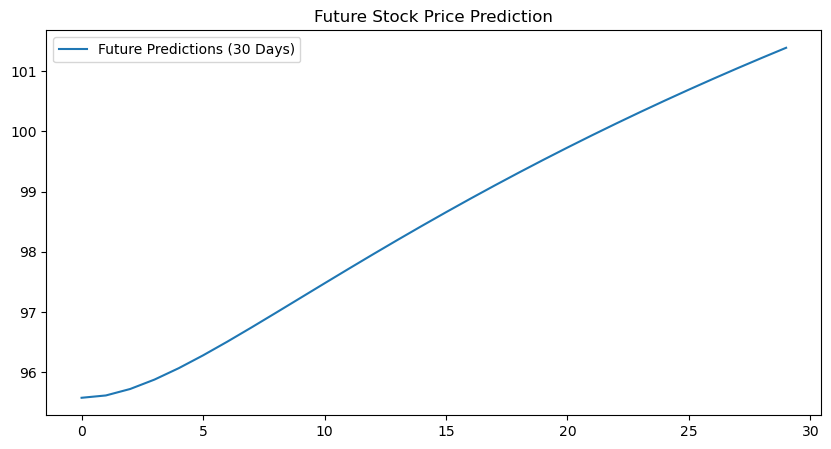

In [35]:
plt.figure(figsize=(10,5))
plt.plot(future_predictions, label="Future Predictions (30 Days)")
plt.legend()
plt.title("Future Stock Price Prediction")
plt.show()